In [5]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
SEED = 42
DEBUG_MODE = True   # change to False for full dataset
IMAGE_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 3 if DEBUG_MODE else 8

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

Device: cpu
CUDA available: False


In [7]:
import kagglehub

path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("Downloaded path:", path)
print("Top-level contents:", os.listdir(path))

100%|██████████| 329M/329M [00:02<00:00, 136MB/s]

Extracting files...


Downloaded path: /root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1
Top-level contents: ['PlantVillage']


In [8]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

def folder_has_images(folder_path):
    try:
        for f in os.listdir(folder_path):
            if f.lower().endswith(IMAGE_EXTENSIONS):
                return True
    except:
        return False
    return False

def find_imagefolder_root(start_path):
    best_root = None
    best_count = 0

    for root, dirs, files in os.walk(start_path):
        image_child_dirs = []
        for d in dirs:
            child = os.path.join(root, d)
            if folder_has_images(child):
                image_child_dirs.append(d)

        if len(image_child_dirs) > best_count:
            best_count = len(image_child_dirs)
            best_root = root

    return best_root, best_count

dataset_root, class_count = find_imagefolder_root(path)
print("Dataset root:", dataset_root)
print("Number of class folders found:", class_count)
print("Sample class folders:", os.listdir(dataset_root)[:10])

Dataset root: /root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1/PlantVillage
Number of class folders found: 15
Sample class folders: ['Pepper__bell___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot', 'Tomato__Target_Spot']


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [10]:
full_train_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)
full_eval_dataset = datasets.ImageFolder(root=dataset_root, transform=test_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Total images:", len(full_train_dataset))
print("First 10 classes:", class_names[:10])

Number of classes: 15
Total images: 20638
First 10 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [11]:
generator = torch.Generator().manual_seed(SEED)

total_size = len(full_train_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

all_indices = torch.randperm(total_size, generator=generator).tolist()

train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:train_size + val_size]
test_indices = all_indices[train_size + val_size:]

if DEBUG_MODE:
    train_indices = train_indices[:5000]
    val_indices = val_indices[:1000]
    test_indices = test_indices[:1000]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)
test_dataset = Subset(full_eval_dataset, test_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 5000
Validation size: 1000
Test size: 1000


In [12]:
num_workers = 2 if torch.cuda.is_available() else 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

dataloaders = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset)
}

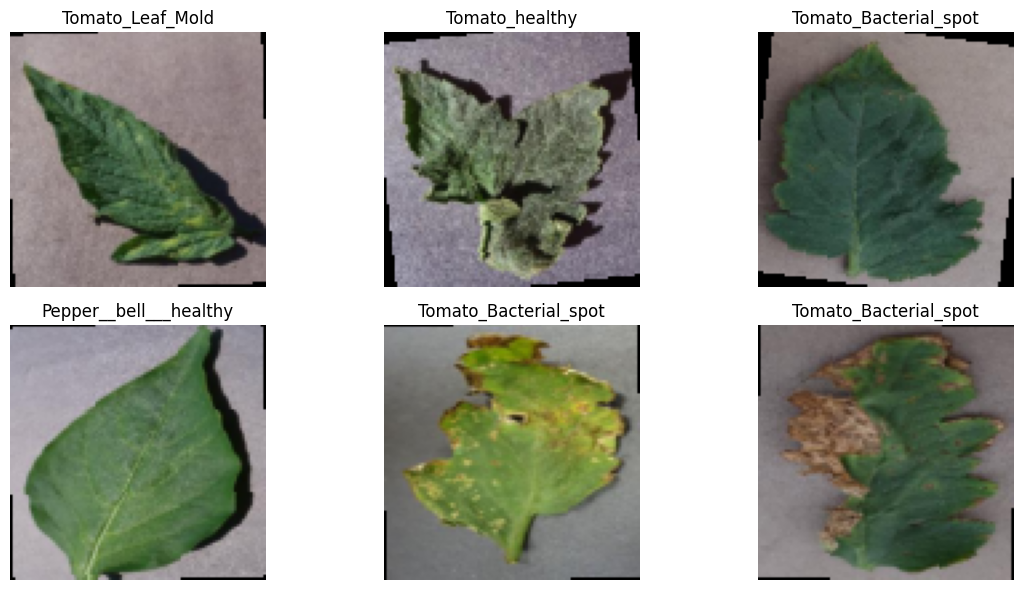

In [13]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
class DeepPlantCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),   # works for 96x96 input
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [16]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, num_epochs=5):
    model = model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 30)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | {phase.capitalize()} Acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    return model, history

In [17]:
def evaluate_model(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(loader.dataset)
    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

    return test_loss, test_acc, np.array(all_labels), np.array(all_preds)

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

In [18]:
DEBUG_MODE = False
EPOCHS = 10

In [19]:
deep_cnn = DeepPlantCNN(num_classes=num_classes)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(deep_cnn.parameters(), lr=0.001)

start_time = time.time()

deep_cnn, cnn_history = train_model(
    deep_cnn,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_cnn,
    num_epochs=EPOCHS
)

print("Deep CNN training time (minutes):", round((time.time() - start_time) / 60, 2))


Epoch 1/10
------------------------------
Train Loss: 2.6598 | Train Acc: 0.2318
Val Loss: 1.9995 | Val Acc: 0.3450

Epoch 2/10
------------------------------
Train Loss: 1.9284 | Train Acc: 0.3658
Val Loss: 1.9090 | Val Acc: 0.3820

Epoch 3/10
------------------------------
Train Loss: 1.6533 | Train Acc: 0.4590
Val Loss: 1.3716 | Val Acc: 0.5640

Epoch 4/10
------------------------------
Train Loss: 1.4652 | Train Acc: 0.5084
Val Loss: 1.9399 | Val Acc: 0.4630

Epoch 5/10
------------------------------
Train Loss: 1.3721 | Train Acc: 0.5444
Val Loss: 1.3407 | Val Acc: 0.5600

Epoch 6/10
------------------------------
Train Loss: 1.2179 | Train Acc: 0.5798
Val Loss: 1.0045 | Val Acc: 0.6650

Epoch 7/10
------------------------------
Train Loss: 1.1370 | Train Acc: 0.6166
Val Loss: 0.9967 | Val Acc: 0.6600

Epoch 8/10
------------------------------
Train Loss: 1.1047 | Train Acc: 0.6330
Val Loss: 1.2034 | Val Acc: 0.6250

Epoch 9/10
------------------------------
Train Loss: 1.0321 | 

Deep CNN Test Loss: 0.6279
Deep CNN Test Accuracy: 0.7910


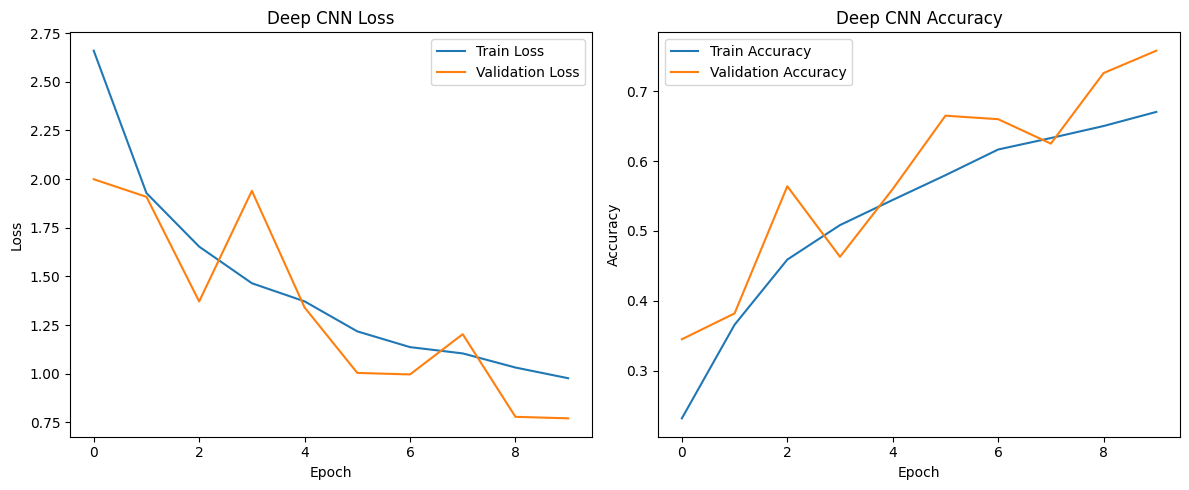

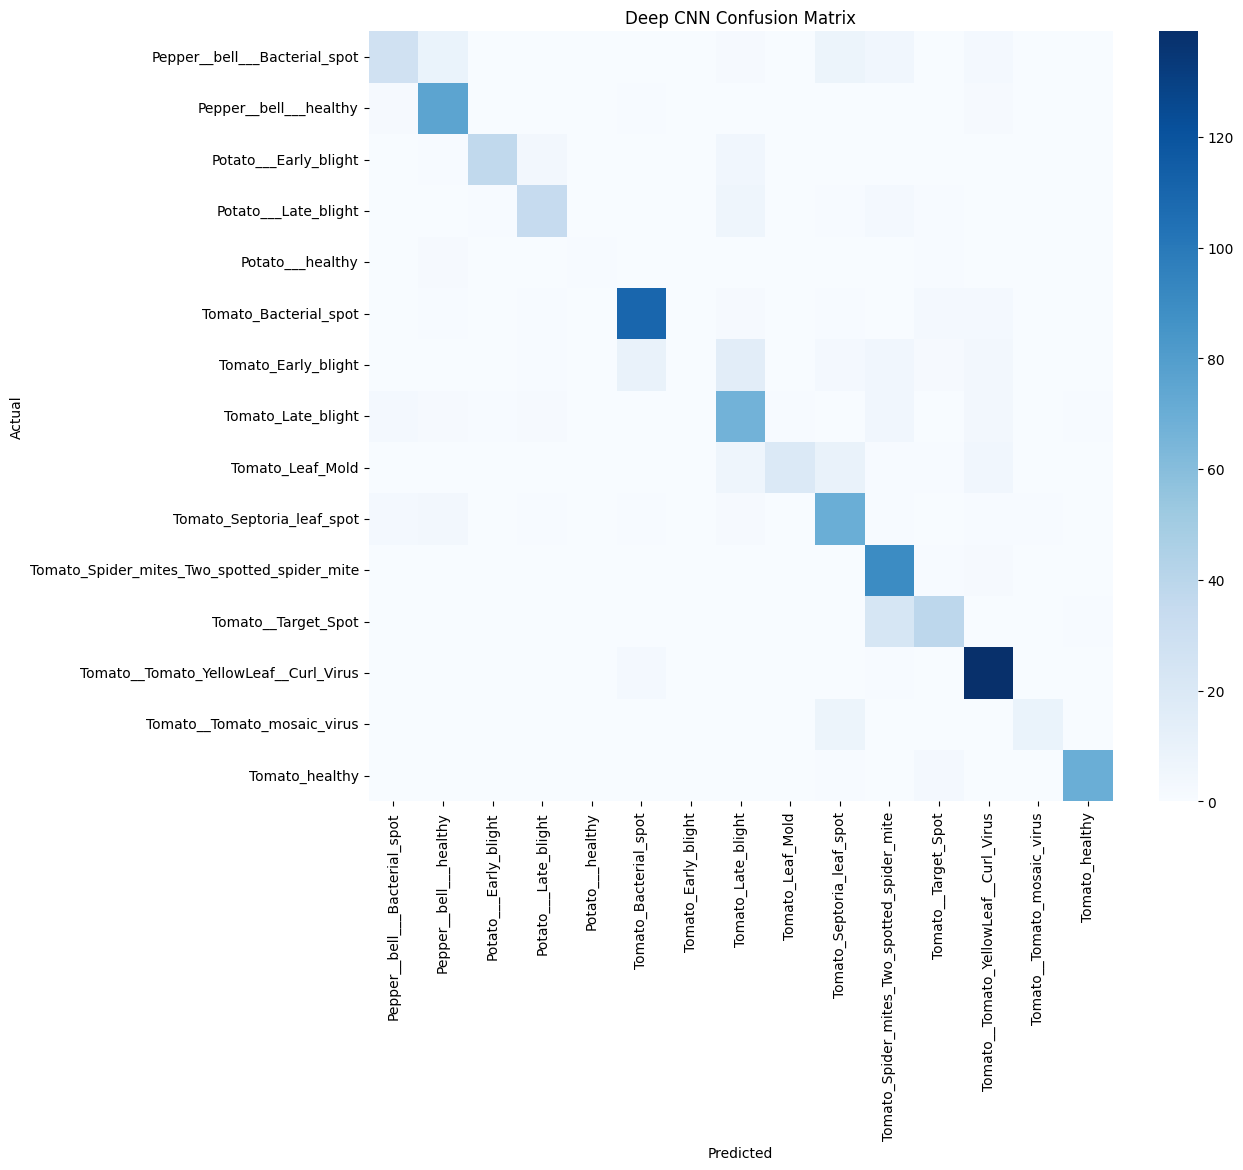

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.78      0.51      0.62        55
                     Pepper__bell___healthy       0.80      0.94      0.86        81
                      Potato___Early_blight       0.95      0.79      0.86        47
                       Potato___Late_blight       0.80      0.73      0.76        48
                           Potato___healthy       1.00      0.25      0.40         4
                      Tomato_Bacterial_spot       0.88      0.91      0.89       121
                        Tomato_Early_blight       0.00      0.00      0.00        40
                         Tomato_Late_blight       0.63      0.78      0.69        86
                           Tomato_Leaf_Mold       0.95      0.45      0.62        44
                  Tomato_Septoria_leaf_spot       0.69      0.83      0.75        84
Tomato_Spider_mites_Two_spotted_spider_mite       0.67      0.97

In [20]:
cnn_test_loss, cnn_test_acc, cnn_true, cnn_pred = evaluate_model(deep_cnn, test_loader)

print(f"Deep CNN Test Loss: {cnn_test_loss:.4f}")
print(f"Deep CNN Test Accuracy: {cnn_test_acc:.4f}")

plot_history(cnn_history, "Deep CNN")
plot_conf_matrix(cnn_true, cnn_pred, class_names, "Deep CNN Confusion Matrix")

In [21]:
resnet18 = build_resnet18(num_classes=num_classes)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=0.001)

start_time = time.time()

resnet18, resnet_history = train_model(
    resnet18,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_resnet,
    num_epochs=EPOCHS
)

print("ResNet18 training time (minutes):", round((time.time() - start_time) / 60, 2))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]



Epoch 1/10
------------------------------
Train Loss: 0.7612 | Train Acc: 0.7582
Val Loss: 0.7778 | Val Acc: 0.7850

Epoch 2/10
------------------------------
Train Loss: 0.4647 | Train Acc: 0.8514
Val Loss: 0.3457 | Val Acc: 0.8980

Epoch 3/10
------------------------------
Train Loss: 0.3275 | Train Acc: 0.8994
Val Loss: 0.3343 | Val Acc: 0.8860

Epoch 4/10
------------------------------
Train Loss: 0.2470 | Train Acc: 0.9164
Val Loss: 0.3118 | Val Acc: 0.9040

Epoch 5/10
------------------------------
Train Loss: 0.2218 | Train Acc: 0.9246
Val Loss: 0.3457 | Val Acc: 0.9000

Epoch 6/10
------------------------------
Train Loss: 0.1993 | Train Acc: 0.9320
Val Loss: 0.2442 | Val Acc: 0.9310

Epoch 7/10
------------------------------
Train Loss: 0.1753 | Train Acc: 0.9418
Val Loss: 0.2781 | Val Acc: 0.9190

Epoch 8/10
------------------------------
Train Loss: 0.1689 | Train Acc: 0.9466
Val Loss: 0.2745 | Val Acc: 0.9050

Epoch 9/10
------------------------------
Train Loss: 0.1247 | 

ResNet18 Test Loss: 0.1645
ResNet18 Test Accuracy: 0.9460


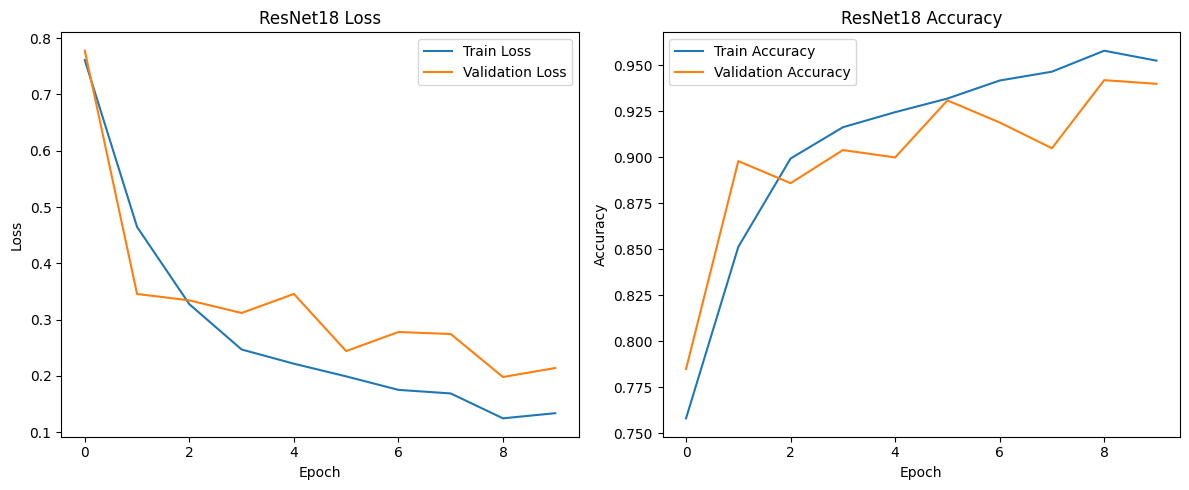

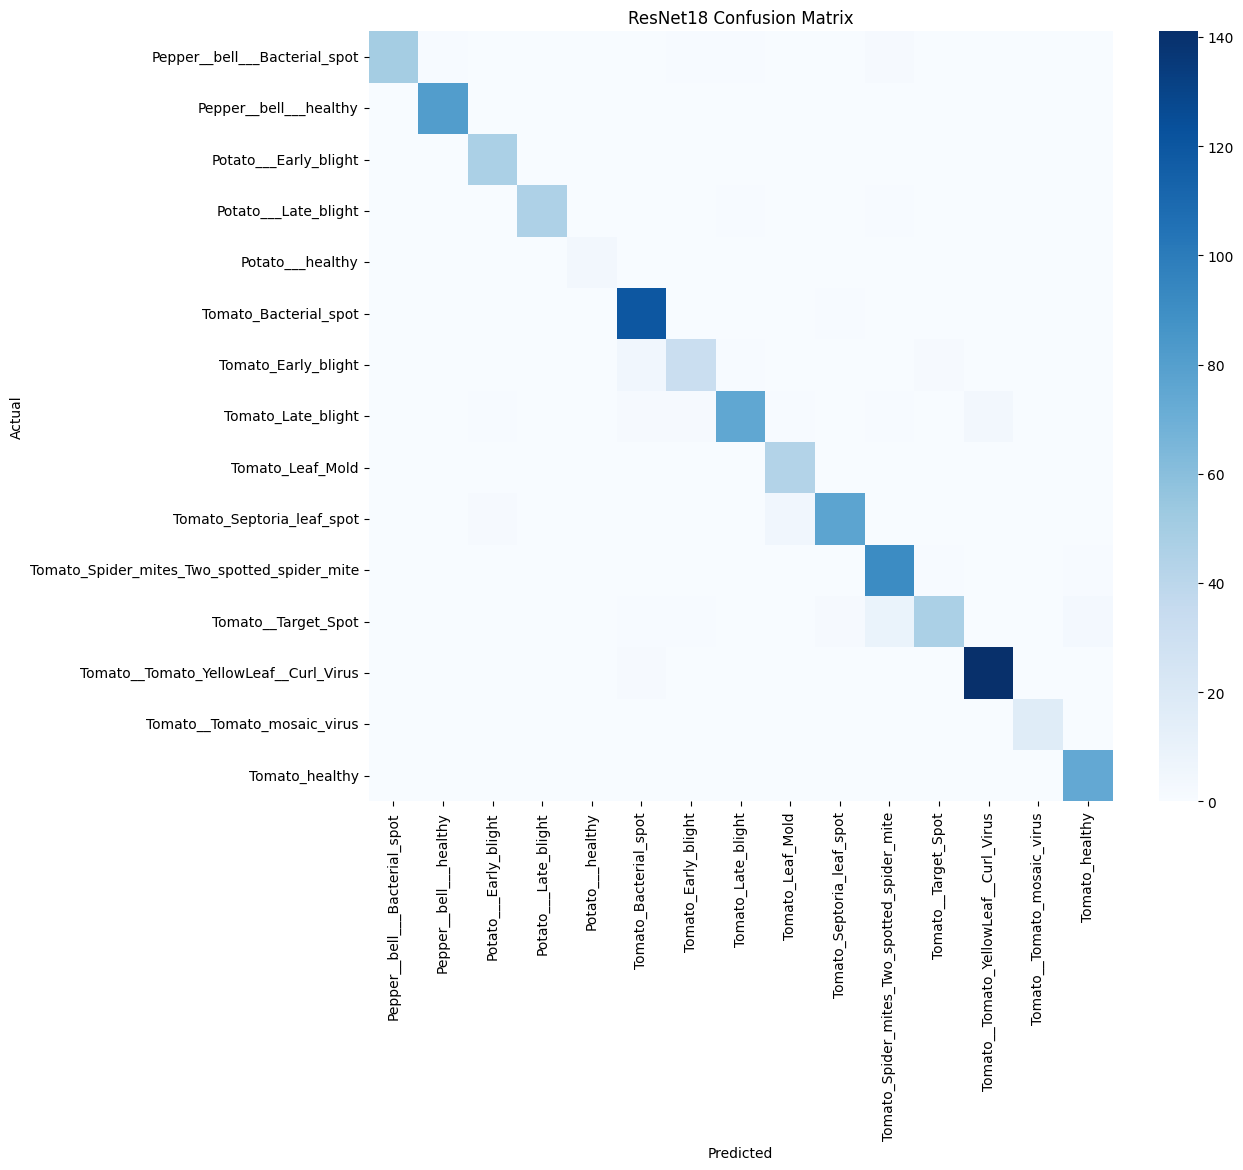

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.91      0.95        55
                     Pepper__bell___healthy       0.99      1.00      0.99        81
                      Potato___Early_blight       0.94      1.00      0.97        47
                       Potato___Late_blight       1.00      0.96      0.98        48
                           Potato___healthy       1.00      1.00      1.00         4
                      Tomato_Bacterial_spot       0.92      0.99      0.96       121
                        Tomato_Early_blight       0.89      0.80      0.84        40
                         Tomato_Late_blight       0.96      0.87      0.91        86
                           Tomato_Leaf_Mold       0.88      1.00      0.94        44
                  Tomato_Septoria_leaf_spot       0.96      0.92      0.94        84
Tomato_Spider_mites_Two_spotted_spider_mite       0.88      0.98

In [22]:
resnet_test_loss, resnet_test_acc, resnet_true, resnet_pred = evaluate_model(resnet18, test_loader)

print(f"ResNet18 Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet18 Test Accuracy: {resnet_test_acc:.4f}")

plot_history(resnet_history, "ResNet18")
plot_conf_matrix(resnet_true, resnet_pred, class_names, "ResNet18 Confusion Matrix")

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Deep CNN", "ResNet18"],
    "Best Validation Accuracy": [
        max(cnn_history["val_acc"]),
        max(resnet_history["val_acc"])
    ],
    "Test Accuracy": [
        cnn_test_acc,
        resnet_test_acc
    ],
    "Test Loss": [
        cnn_test_loss,
        resnet_test_loss
    ]
})

results_df

In [24]:
torch.save(deep_cnn.state_dict(), "deep_cnn_week4.pth")
torch.save(resnet18.state_dict(), "resnet18_week4.pth")

print("Models saved.")

Models saved.


In [25]:
import gradio as gr
from PIL import Image

def predict_image(img):
    img = test_transform(img).unsqueeze(0).to(device)
    resnet18.eval()

    with torch.no_grad():
        outputs = resnet18(img)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx]) * 100

    top3_idx = probs.argsort()[-3:][::-1]
    top3 = {class_names[i]: float(probs[i]) for i in top3_idx}

    summary = f"Prediction: {pred_class}\nConfidence: {confidence:.2f}%"
    return summary, top3

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="Prediction Summary"),
        gr.Label(label="Top 3 Probabilities")
    ],
    title="Plant Disease Detection System",
    description="Upload a leaf image to classify plant disease using ResNet18."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6cf4533a04753cc2df.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
